# The Cost of Change: Tracking Treatment Duration Through a 2025 Facility Reorganization

This analysis will explore how a organizational re-structuring in August 2025 affected the length of stay at a Substance Use Treatment facility in Minnesota. 

# Data Cleaning & Prep

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load data
los = pd.read_excel("Length of Stay Data.xlsx")

In [4]:
# column conversion
los['Subject_ID'] = pd.to_numeric(los['Subject_ID'], errors='coerce')
los['Program'] =  los['Program'].astype('category')
los['Admission_Date'] = pd.to_datetime(los['Admission_Date'], errors='coerce')
los['Date_of_Discharge'] = pd.to_datetime(los['Date_of_Discharge'], errors='coerce')
los['Reason_for_Discharge'] = los['Reason_for_Discharge'].astype('str')

# standardize strings
string_col = los.select_dtypes(include=['string'])
column_list = string_col.columns.to_list()
los[column_list] = los[column_list].apply(lambda x: x.str.lower())

In [5]:
# apply filters

#filter discharge date
discharged_filter = los['Date_of_Discharge'].between('2025-02-01', '2026-03-31')
los = los[discharged_filter]
#print(los['Date_of_Discharge'].min(), los['Date_of_Discharge'].max())

# filter discharge reason
target_strings = ['completed program', 'patient left without staff approval', 'patient conduct (behavioral)']
los = los[los['Reason_for_Discharge'].isin(target_strings)]
#los['Reason_for_Discharge'].value_counts()

In [6]:
# create lengt of stay column
los['Length_of_Stay'] = (los['Date_of_Discharge'] - los['Admission_Date']).dt.days + 1

#create before and after period categories
los['Period'] = los['Date_of_Discharge'].apply(lambda x: 'before' if x < pd.to_datetime('2025-08-31') else 'after')
los['Period'] = los['Period'].astype('category')
#los['Period'].value_counts()

#create discharge type categories (successful vs unsuccessful)
def discharge_type(reason):
    if reason == 'completed program':
        return 'successful'
    else:
        return 'unsuccessful'
    
los['Discharge_Type'] = los['Reason_for_Discharge'].apply(discharge_type)
los['Discharge_Type'] = los['Discharge_Type'].astype('category')
#los['Discharge_Type'].value_counts()
los

,Subject_ID,Program,Admission_Date,Date_of_Discharge,Reason_for_Discharge,Length_of_Stay,Period,Discharge_Type
0,1,Women's Residential Treatment Center,2026-03-04,2026-03-04,patient left without staff approval,1,after,unsuccessful
1,2,Women's Residential Treatment Center,2025-03-24,2025-04-14,patient conduct (behavioral),22,before,unsuccessful
2,3,Women's Residential Treatment Center,2025-06-16,2025-06-18,patient left without staff approval,3,before,unsuccessful
3,3,Women's Residential Treatment Center,2025-08-08,2025-08-13,patient conduct (behavioral),6,before,unsuccessful
6,6,Women's Residential Treatment Center,2026-02-04,2026-02-05,patient left without staff approval,2,after,unsuccessful
...,...,...,...,...,...,...,...,...
326,302,Women's Residential Treatment Center,2026-02-25,2026-02-26,patient left without staff approval,2,after,unsuccessful
328,304,Women's Residential Treatment Center,2026-02-26,2026-03-06,patient left without staff approval,9,after,unsuccessful
329,305,Women's Residential Treatment Center,2026-02-26,2026-03-27,patient left without staff approval,30,after,unsuccessful
330,306,Women's Residential Treatment Center,2026-03-05,2026-03-06,patient left without staff approval,2,after,unsuccessful


# Exploring Categorical Variables

Period
after     0.58042
before    0.41958
Name: proportion, dtype: float64


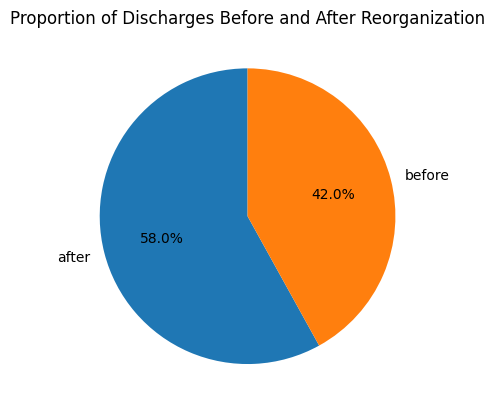

In [7]:
# before vs after

print(los['Period'].value_counts(normalize=True))

plt.pie(los['Period'].value_counts(), labels=los['Period'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Discharges Before and After Reorganization')
plt.show()

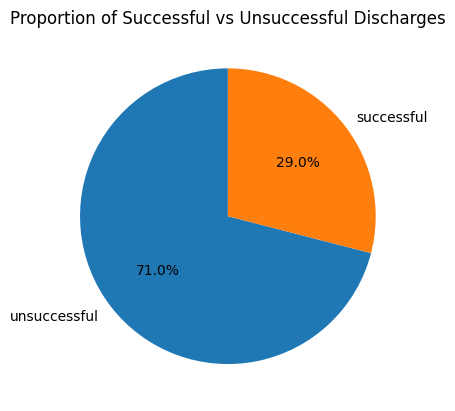

In [20]:
#successful vs unsuccessful

fig, ax = plt.subplots()

#overall
ax.pie(los['Discharge_Type'].value_counts(), labels=los['Discharge_Type'].value_counts().index, autopct='%1.1f%%', startangle=90)
ax.set_title('Proportion of Successful vs Unsuccessful Discharges')
plt.show()